<a href="https://colab.research.google.com/github/hdflorez/Entrega_2/blob/main/dataset_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de Datos (190304018-1 ) 2026-1** | **Entrega 2** |

**Integrantes del equipo:**
*   Mariana Villegas Ochoa
*   Melisa Colorado Soto
*   Jaider Santiago Villa David
*   Hernán Darío Flórez Martínez
---


# **Fase 1: Exploración de Base de datos** | **Dataset 1: Stroke Prediction** |

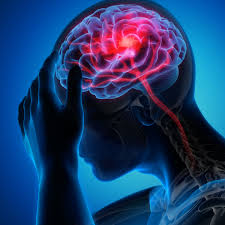

## **Generalidades del dataset**
De acuerdo con la OMS, el ictus ocupa el segundo lugar entre las principales causas de mortalidad en el mundo, siendo responsable de cerca del 11 % de todas las muertes registradas. El presente conjunto de datos tiene como objetivo estimar la probabilidad de que un paciente desarrolle un ictus, a partir de variables como el género, la edad, antecedentes de enfermedades y el consumo de tabaco, donde cada registro incluye información clínica y personal relevante del paciente.

Sus aplicaciones potenciales abarcan la predicción de accidentes cerebrovasculares, el desarrollo de modelos de Machine Learning y Deep Learning, y el apoyo en el diagnóstico médico.

Se trata de un dataset de tipo secundario disponible en Kaggle, derivado de datos clínicos reales, y puede consultarse en: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset?select=healthcare-dataset-stroke-data.csv

  ## Fuente y tipo de datos
•	Dataset de Kaggle

•	Tipo: Secundario (proviene de varias bases clínicas previas)

## Características
•	Registros: 918

•	Atributos: 12 (11 variables + 1 objetivo)

•	Tamaño: ~36 KB

•	Tipo de problema: Clasificación binaria (enfermedad cardíaca: sí/no)

## Posibles aplicaciones:

•	Predicción de enfermedades cardíacas

•	Modelos de Machine Learning y Deep Learning

•	Apoyo a diagnóstico médico

In [ ]:
#Importe de librerías
import kagglehub
import os

# Descarga del dataset
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Dataset downloaded to: /kaggle/input/stroke-prediction-dataset


In [ ]:
import os

print(os.listdir(path))

['healthcare-dataset-stroke-data.csv']


In [ ]:
# Bloque 1: Importación de librerías y carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para visualizaciones
plt.style.use('default')
sns.set_palette("husl")

# Ubicación del dataset
path_dataset = path + "/healthcare-dataset-stroke-data.csv"

# Cargar el dataset
df = pd.read_csv(path_dataset)

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 5110, Columnas: 12


=== ANÁLISIS DE VALORES FALTANTES ===
Resumen de valores faltantes:
     Faltantes         %
bmi        201  3.933464


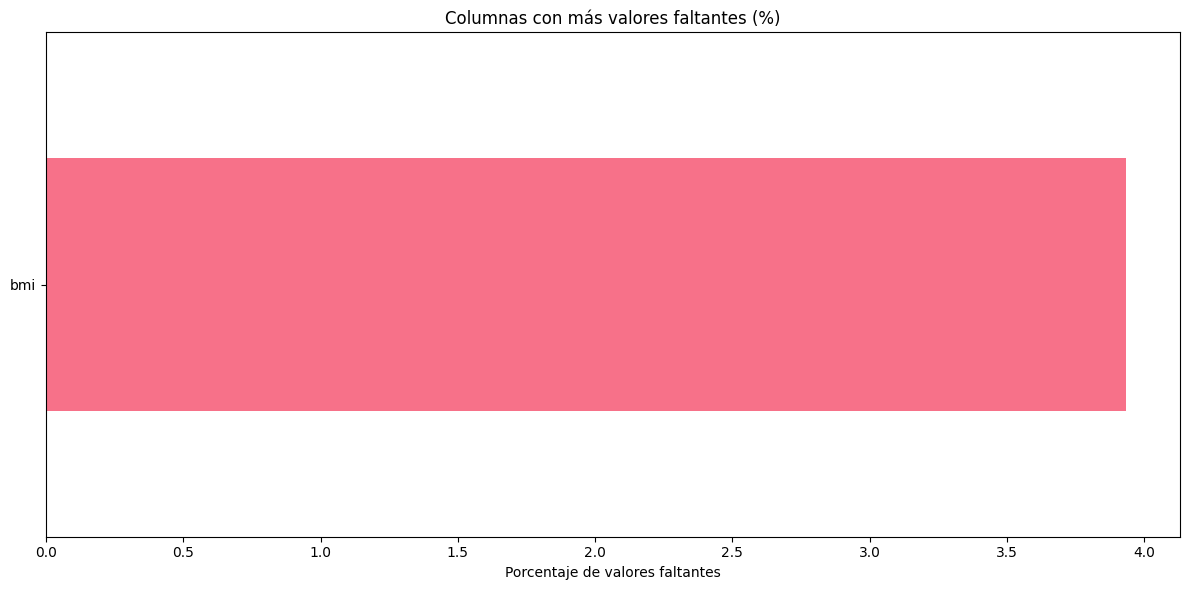

In [ ]:
print("=== ANÁLISIS DE VALORES FALTANTES ===")

# Calcular valores faltantes
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

# Crear dataframe resumen
missing_df = pd.concat([missing, missing_percent], axis=1)
missing_df.columns = ["Faltantes", "%"]

# Filtrar solo columnas con faltantes
missing_filtered = missing_df[missing_df["Faltantes"] > 0]

print("Resumen de valores faltantes:")
print(missing_filtered)

# Visualización (solo si hay datos)
if not missing_filtered.empty:
    plt.figure(figsize=(12, 6))
    missing_plot = missing_filtered["%"].head(10)

    missing_plot.plot(kind='barh')
    plt.title('Columnas con más valores faltantes (%)')
    plt.xlabel('Porcentaje de valores faltantes')
    plt.tight_layout()
    plt.show()
else:
    print("No hay valores faltantes en el dataset")